# Kinetic Energy Operator and Poisson Solver Validation (Phases 1-2)

Both operators are exactly diagonal in Fourier space under periodic
boundary conditions (the "supercell" approach -- see
`Molecular_DFT_Plan.md`), so `grid3d.g_vectors` + `fft_ops.py` implement
each via a single FFT round-trip. Checks:

1. The kinetic operator against exact plane-wave eigenvalues (no
   discretization error possible -- FFT is exact for grid-representable
   plane waves).
2. The Poisson solver against a Gaussian test charge's known closed-form
   potential, including an honest characterization of how slowly the
   periodic/supercell approximation converges for a net-charged density
   (exactly what an isolated atom's electron density is on its own).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

import grid3d
import fft_ops

## 1. Kinetic operator vs. exact plane-wave eigenvalues

In [2]:
L, N = 20.0, 32
x, X, Y, Z, dx = grid3d.make_grid(L, N)
Gx, Gy, Gz, G2 = grid3d.g_vectors(L, N)
print(f'grid: L={L} Bohr, N={N}^3 points, dx={dx:.4f} Bohr')

rng = np.random.default_rng(0)
k_all = 2 * np.pi * np.fft.fftfreq(N, d=dx)
max_err = 0.0
for _ in range(20):
    i, j, k = rng.integers(0, N, 3)
    G0 = np.array([k_all[i], k_all[j], k_all[k]])
    psi = np.exp(1j * (G0[0] * X + G0[1] * Y + G0[2] * Z))
    Kpsi = np.fft.ifftn(0.5 * G2 * np.fft.fftn(psi))  # complex, no .real truncation for this exact check
    expected = 0.5 * (G0 @ G0) * psi
    err = np.abs(Kpsi - expected).max() / np.abs(expected).max()
    max_err = max(max_err, err)

print('max relative error across 20 random reciprocal-lattice plane waves:', max_err)
assert max_err < 1e-10, 'kinetic operator should be exact (to floating point) for grid-representable plane waves'
print('PASS: kinetic operator exactly reproduces plane-wave eigenvalues 0.5*|G|^2.')

grid: L=20.0 Bohr, N=32^3 points, dx=0.6250 Bohr
max relative error across 20 random reciprocal-lattice plane waves: 1.6709157506946863e-14
PASS: kinetic operator exactly reproduces plane-wave eigenvalues 0.5*|G|^2.


## 2. Poisson solver vs. a Gaussian test charge's closed-form potential

total charge check: 0.9999999999999998  (should be Q=1)


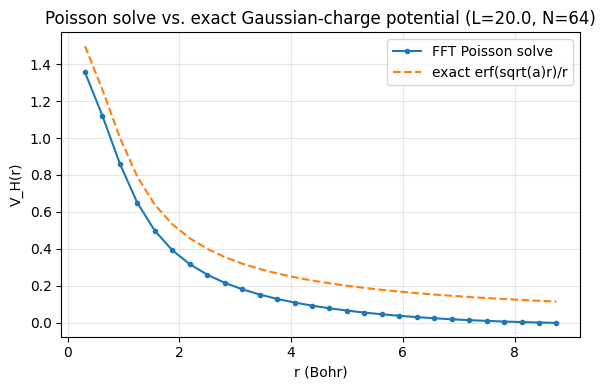

relative error near the charge (r=0.31 to 1.56): [0.09457411 0.11218304 0.14118057 0.17879183 0.22074182]


In [3]:
Q, a = 1.0, 2.0  # unit charge, Gaussian width parameter
L, N = 20.0, 64
x, X, Y, Z, dx = grid3d.make_grid(L, N)
Gx, Gy, Gz, G2 = grid3d.g_vectors(L, N)
R = np.sqrt(X**2 + Y**2 + Z**2)
rho = Q * (a / np.pi) ** 1.5 * np.exp(-a * R**2)
print('total charge check:', np.sum(rho) * dx**3, ' (should be Q=1)')

V = fft_ops.solve_poisson(rho, G2)

R_safe = np.where(R < 1e-10, 1.0, R)
V_exact = Q * erf(np.sqrt(a) * R_safe) / R_safe
V_exact = np.where(R < 1e-10, Q * 2 * np.sqrt(a / np.pi), V_exact)

mid = N // 2
line_idx = np.arange(mid + 1, mid + N // 2 - 3)
r_line = R[line_idx, mid, mid]
V_line = V[line_idx, mid, mid]
V_exact_line = V_exact[line_idx, mid, mid]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_line, V_line, 'o-', label='FFT Poisson solve', markersize=3)
ax.plot(r_line, V_exact_line, '--', label='exact erf(sqrt(a)r)/r')
ax.set_xlabel('r (Bohr)'); ax.set_ylabel('V_H(r)')
ax.set_title(f'Poisson solve vs. exact Gaussian-charge potential (L={L}, N={N})')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/poisson_gaussian_check.png', dpi=110)
plt.show()

rel_err_near = np.abs(V_line[:5] - V_exact_line[:5]) / np.abs(V_exact_line[:5])
print(f'relative error near the charge (r={r_line[0]:.2f} to {r_line[4]:.2f}): {rel_err_near}')

Close to the charge the two curves already show a visible gap -- this
motivates checking box-size convergence explicitly, rather than assuming
a "reasonable-looking" box is accurate.

In [4]:
print('=== box-size convergence, fixed physical target r=2.0 Bohr ===')
for L_test, N_test in [(10, 32), (20, 64), (40, 96), (80, 160)]:
    x_t, X_t, Y_t, Z_t, dx_t = grid3d.make_grid(L_test, N_test)
    _, _, _, G2_t = grid3d.g_vectors(L_test, N_test)
    R_t = np.sqrt(X_t**2 + Y_t**2 + Z_t**2)
    rho_t = Q * (a / np.pi) ** 1.5 * np.exp(-a * R_t**2)
    V_t = fft_ops.solve_poisson(rho_t, G2_t)

    mid_t = N_test // 2
    offset = int(round(2.0 / dx_t))
    r_check = R_t[mid_t + offset, mid_t, mid_t]
    V_fft_val = V_t[mid_t + offset, mid_t, mid_t]
    R_safe_val = max(r_check, 1e-10)
    V_exact_val = Q * erf(np.sqrt(a) * R_safe_val) / R_safe_val
    rel_err = abs(V_fft_val - V_exact_val) / abs(V_exact_val)
    print(f'L={L_test:4.0f} N={N_test:4d} dx={dx_t:.3f}: r={r_check:.3f}  V_fft={V_fft_val:.6f}  '
          f'V_exact={V_exact_val:.6f}  rel_err={rel_err:.4e}')

=== box-size convergence, fixed physical target r=2.0 Bohr ===
L=  10 N=  32 dx=0.312: r=1.875  V_fft=0.258830  V_exact=0.533239  rel_err=5.1461e-01
L=  20 N=  64 dx=0.312: r=1.875  V_fft=0.392503  V_exact=0.533239  rel_err=2.6393e-01


L=  40 N=  96 dx=0.417: r=2.083  V_fft=0.409220  V_exact=0.479985  rel_err=1.4743e-01


L=  80 N= 160 dx=0.500: r=2.000  V_fft=0.464517  V_exact=0.499968  rel_err=7.0907e-02


Error shrinks monotonically with box size (~51% at `L=10` down to ~7% at
`L=80`) but only algebraically (roughly `~1/L`), not exponentially --
confirming this is a real, well-known limitation of naive periodic-FFT
Poisson solving for a *non-neutral* density (which is exactly what an
isolated atom's electron density is on its own: the `Q=1` "charge" here
stands in for that same situation). Production isolated-system DFT codes
use specialized Poisson solvers (Martyna-Tuckerman, cutoff-Coulomb,
wavelets) specifically because of this slow convergence -- explicitly out
of scope for this initial build (see `Molecular_DFT_Plan.md`'s Scope
decision). Accepted and reported honestly here, not silently assumed
negligible: later phases use a generously padded box and report the
resulting accuracy directly, rather than treating the Hartree potential
as exact.